In [1]:

import importlib
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import prism
import warnings
import copy
import logging

import imagematerials.buildings.constants as bld_const
import imagematerials.buildings.preprocessing.circular_economy_measures as ce_mod
import imagematerials.buildings.preprocessing.main as bld_main
from imagematerials.util import read_circular_economy_config, read_climate_policy_config
from imagematerials.buildings.preprocessing.population import compute_population
from imagematerials.concepts import create_region_graph
from imagematerials.constants import IMAGE_REGIONS

# Force reload so the kernel picks up latest code
importlib.reload(bld_const)
importlib.reload(ce_mod)
importlib.reload(bld_main)
from imagematerials.buildings.preprocessing.main import buildings_preprocessing


In [2]:

base_dir = Path("..", "data", "raw")
climate_dir = Path("..", "..", "data", "IMAGE_CircoMod", "SSP2")
climate_dir_narrow_act = Path("..", "..", "data", "IMAGE_CircoMod", "SSP2_narrow_act")
ce_dir_base = {
    "base": base_dir / "circular_economy_scenarios" / "base",
}
ce_dir_narrow_act = {
    "base": base_dir / "circular_economy_scenarios" / "base",
    "narrow_activity": base_dir / "circular_economy_scenarios" / "narrow_activity",
}

climate_config = read_climate_policy_config(climate_dir)
climate_config_narrow_act = read_climate_policy_config(climate_dir_narrow_act)

logging.basicConfig(
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s',
    force=True
)

comm_types = ["Office", "Retail+", "Hotels+", "Govt+"]
results = {}
prep_store = {}  # full prep_data dicts for model runs
ce_cfg = read_circular_economy_config(ce_dir_narrow_act)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    # CE = None
    from imagematerials.preprocessing import get_preprocessing_data
    prep_none = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_dir, None)
    results["none"] = prep_none.prep_data["stocks"].sel(Type=comm_types).sum("Type")

    # CE = base
    prep_base = buildings_preprocessing(base_dir, climate_config, read_circular_economy_config(ce_dir_base))
    results["base"] = prep_base["stocks"].sel(Type=comm_types).sum("Type")
    prep_store["base"] = prep_base

    # CE = narrow_activity (relative & convergence) — uses SSP2_narrow_act climate
    for mode in ("relative", "convergence"):
        ce_cfg_run = copy.deepcopy(ce_cfg)
        ce_cfg_run["narrow_activity"]["buildings"]["commercial_ce_mode"] = mode
        print(f"--- Running mode: {mode} ---")
        prep = buildings_preprocessing(base_dir, climate_config_narrow_act, ce_cfg_run)
        results[mode] = prep["stocks"].sel(Type=comm_types).sum("Type")
        prep_store[mode] = prep

# --- Compute population (rebroadcast to named IMAGE regions) ---
image_dir = Path(climate_config["config_file_path"])
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    population = compute_population(image_dir, base_dir)

knowledge_graph_region = create_region_graph()
population = knowledge_graph_region.rebroadcast_xarray(
    population, output_coords=IMAGE_REGIONS, dim="Region")
pop_total = population.sel(Area="Total")

# --- Shared plot helpers ---
all_regions = list(results["relative"].coords["Region"].values)
cmap = plt.cm.get_cmap("tab20", len(all_regions))
region_colors = {reg: cmap(i) for i, reg in enumerate(all_regions)}


pint.util - WARNING - Redefining 'percent' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining '%' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'base' for Residential Buildings


--- Running mode: relative ---


root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'narrow_activity' for Commercial Buildings with 'relative' target
root - DEBUG - implemented 'base' for Residential Buildings


--- Running mode: convergence ---


root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'narrow_activity' for Commercial Buildings with 'convergence' target
root - DEBUG - implemented 'base' for Residential Buildings
C:\Users\5982758\AppData\Local\Temp\ipykernel_31224\2986950958.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_regions))


matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - 

matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotli

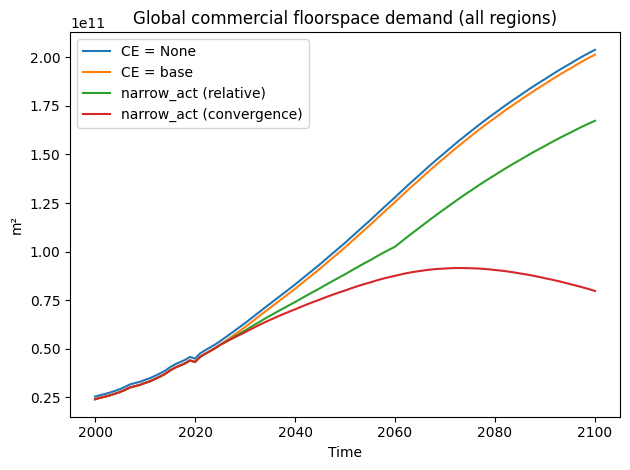

In [3]:

# Global commercial floorspace stock: all scenarios
scenario_labels = {"none": "CE = None", "base": "CE = base",
                   "relative": "narrow_act (relative)", "convergence": "narrow_act (convergence)"}

for key, label in scenario_labels.items():
    total = results[key].sum("Region").loc[2000:]
    if prism.U_(total) is not None:
        total = total.pint.to("m**2")
    total.plot(label=label)

plt.legend()
plt.ylabel("m²")
plt.title("Global commercial floorspace demand (all regions)")
plt.tight_layout()
plt.show()


matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=7.0.
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral'

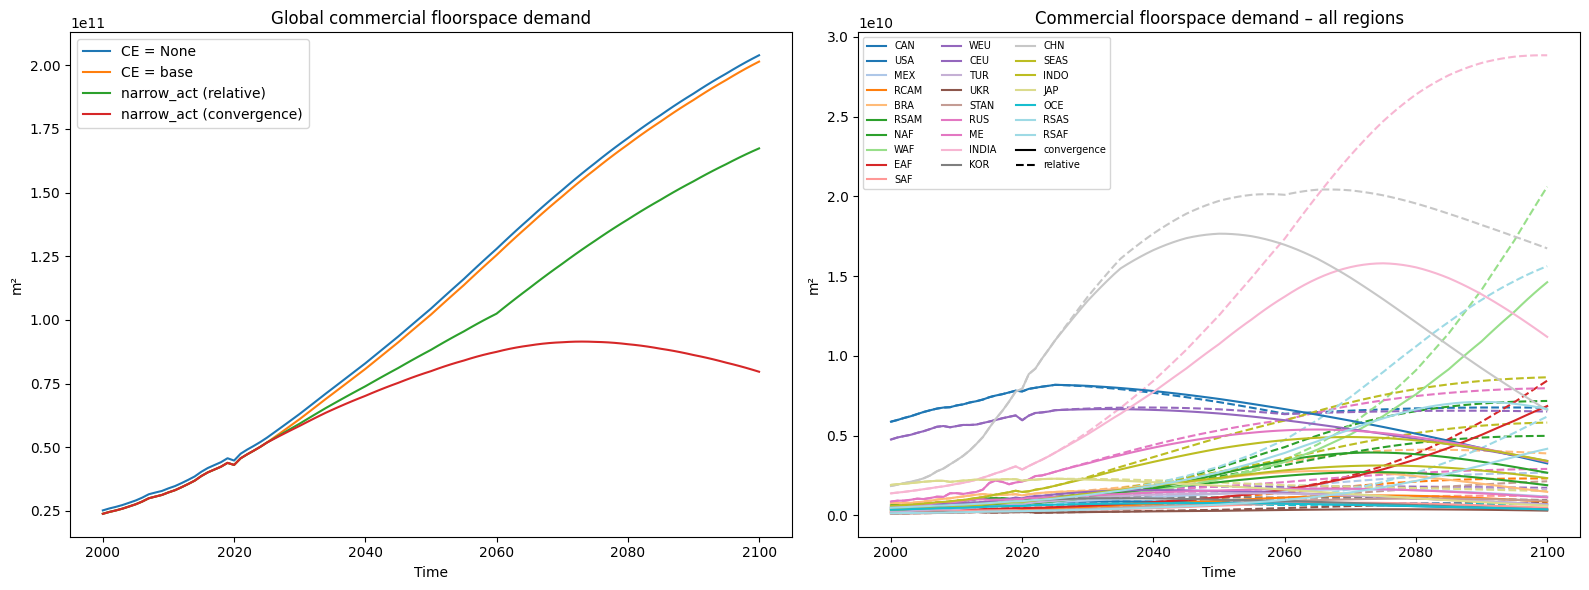

In [4]:

# --- Left: Global total with all scenarios. Right: Per-region (relative vs convergence) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scenario_labels = {"none": "CE = None", "base": "CE = base",
                   "relative": "narrow_act (relative)", "convergence": "narrow_act (convergence)"}
for key, label in scenario_labels.items():
    total = results[key].sum("Region").loc[2000:]
    if prism.U_(total) is not None:
        total = total.pint.to("m**2")
    total.plot(ax=axes[0], label=label)
axes[0].set_title("Global commercial floorspace demand")
axes[0].set_ylabel("m²")
axes[0].legend()

for mode in ("relative", "convergence"):
    linestyle = "-" if mode == "convergence" else "--"
    for reg in all_regions:
        series = results[mode].sel(Region=reg).loc[2000:]
        if prism.U_(series) is not None:
            series = series.pint.to("m**2")
        series.plot(ax=axes[1], linestyle=linestyle, color=region_colors[reg])

handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="convergence"))
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="relative"))
axes[1].legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
axes[1].set_title("Commercial floorspace demand – all regions")
axes[1].set_ylabel("m²")

plt.tight_layout()
plt.show()


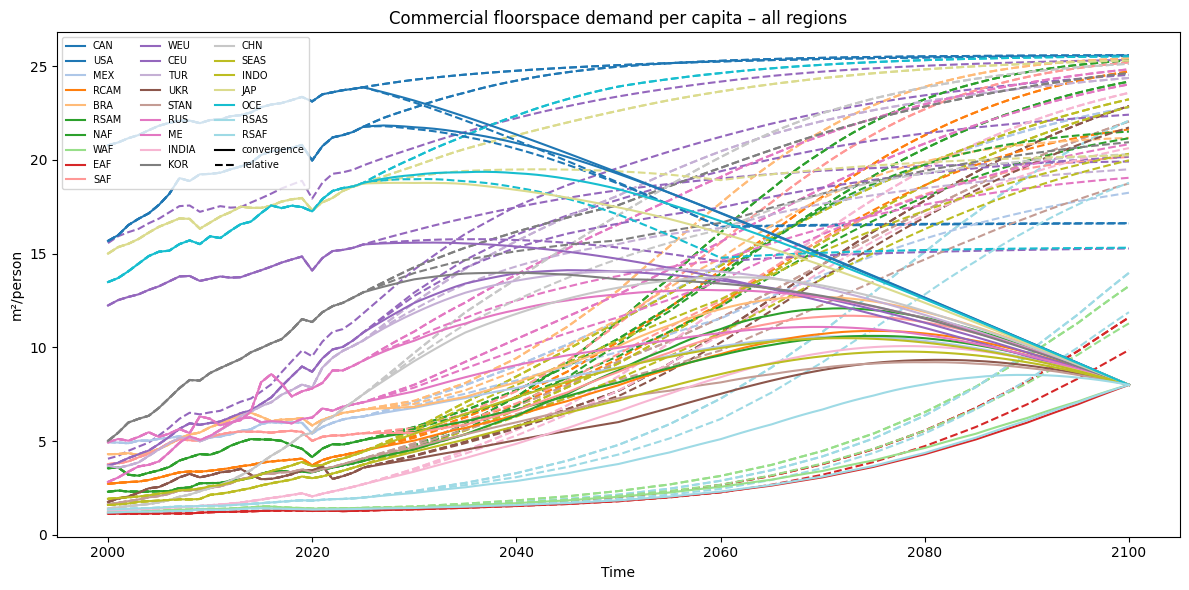

In [5]:

# --- Per-capita comparison: all regions ---
fig, ax = plt.subplots(figsize=(12, 6))

for mode, stocks in results.items():
    linestyle = "-" if mode == "convergence" else "--"
    for reg in all_regions:
        series = stocks.sel(Region=reg).loc[2000:]
        pop_reg = pop_total.sel(Region=reg).loc[2000:]
        per_cap = series / pop_reg
        if prism.U_(per_cap) is not None:
            per_cap = per_cap.pint.to("m**2/person")
        per_cap.plot(ax=ax, linestyle=linestyle, color=region_colors[reg])

handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="convergence"))
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="relative"))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Commercial floorspace demand per capita – all regions")
ax.set_ylabel("m²/person")

plt.tight_layout()
plt.show()


In [6]:

# --- Run the full model (with lifetime dynamics) for base, relative, convergence ---
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import GenericStocks

complete_timeline = prism.Timeline(1971, 2100, 1)
simulation_timeline = prism.Timeline(1971, 2100, 1)

model_results = {}  # key -> model.buildings dict

for scen, prep_data in prep_store.items():
    sector = Sector("buildings", prep_data)
    model = ModelFactory(
        [sector], complete_timeline
    ).add(GenericStocks, ["buildings"]).finish()

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    model_results[scen] = dict(model.buildings)
    print(f"Finished model run: {scen}")

print("Available keys:", list(model_results["base"].keys()))


pint.util - WARNING - Redefining 'person' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'persons' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'people' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'meter' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'm' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'share' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'ratio' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'fraction' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'US_Dollar' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'USD' (<class 'pint.delegates.txt

Finished model run: base
Finished model run: relative
Finished model run: convergence
Available keys: ['stocks', 'lifetimes', 'material_intensities', 'knowledge_graph', 'set_unit_flexible', 'outflow_by_cohort', 'inflow', 'stock_by_cohort']


matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral'

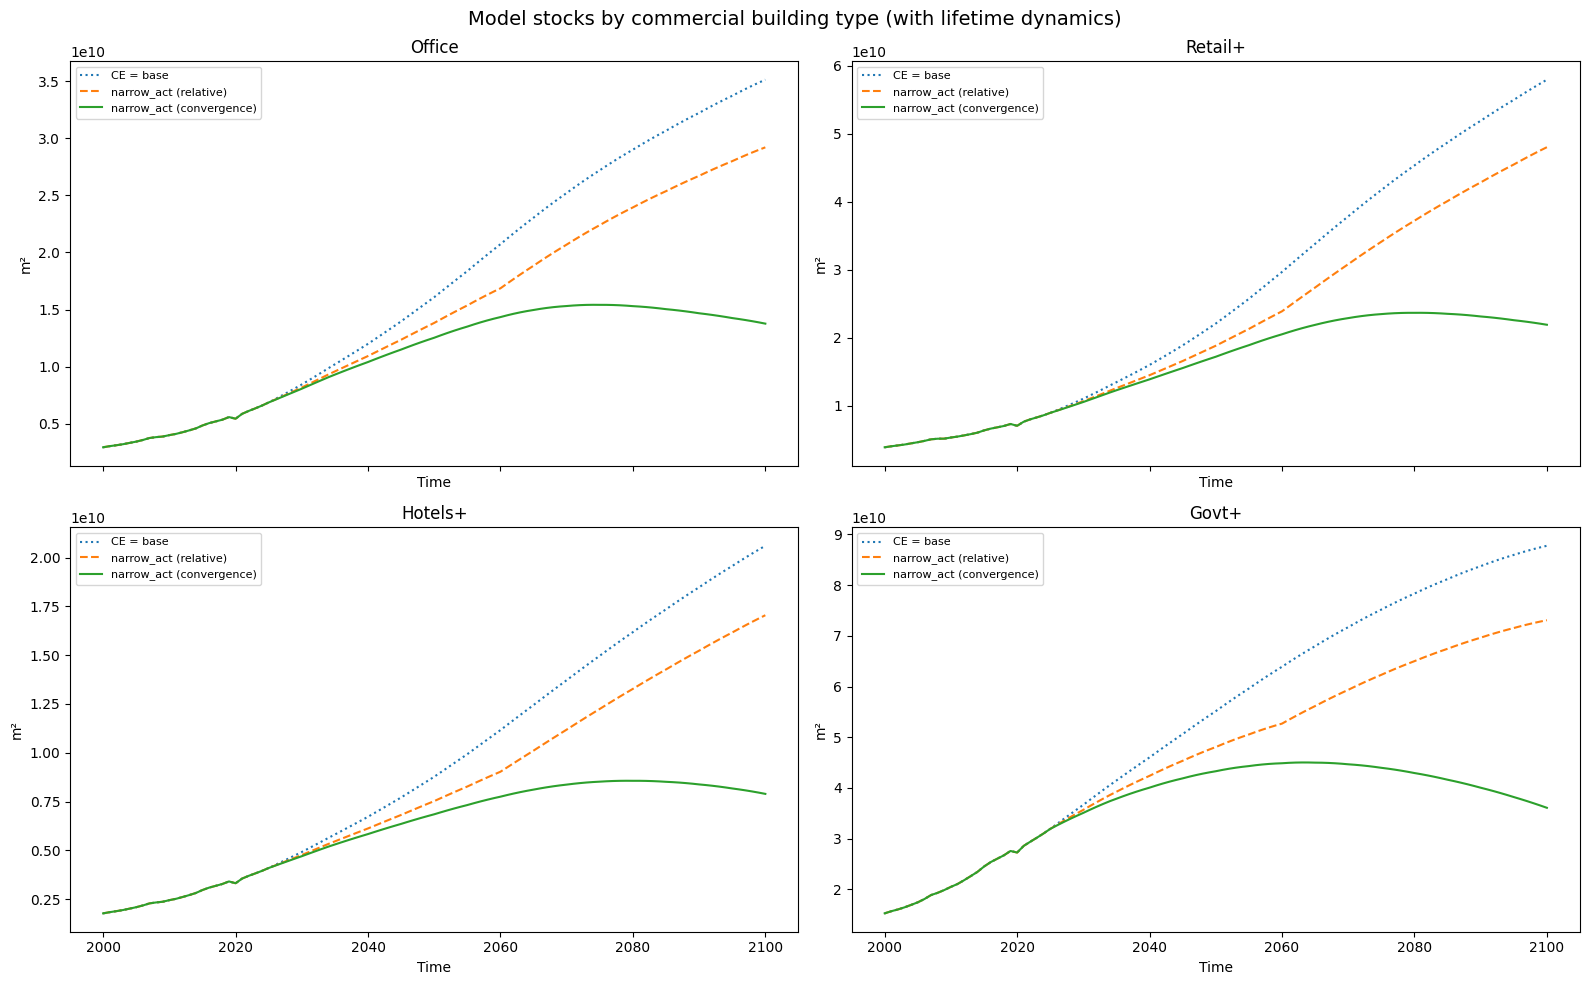

In [7]:

# --- Model stocks per commercial building type (with lifetime dynamics) ---
comm_types_plot = ["Office", "Retail+", "Hotels+", "Govt+"]
scen_labels = {"base": "CE = base", "relative": "narrow_act (relative)", "convergence": "narrow_act (convergence)"}
scen_styles = {"base": ":", "relative": "--", "convergence": "-"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes_flat = axes.flatten()

for i, btype in enumerate(comm_types_plot):
    ax = axes_flat[i]
    for scen, label in scen_labels.items():
        stock = model_results[scen]["stocks"].sel(Type=btype).sum("Region").loc[2000:]
        if prism.U_(stock) is not None:
            stock = stock.pint.to("m**2")
        stock.plot(ax=ax, label=label, linestyle=scen_styles[scen])
    ax.set_title(btype)
    ax.set_ylabel("m²")
    ax.legend(fontsize=8)

fig.suptitle("Model stocks by commercial building type (with lifetime dynamics)", fontsize=14)
plt.tight_layout()
plt.show()


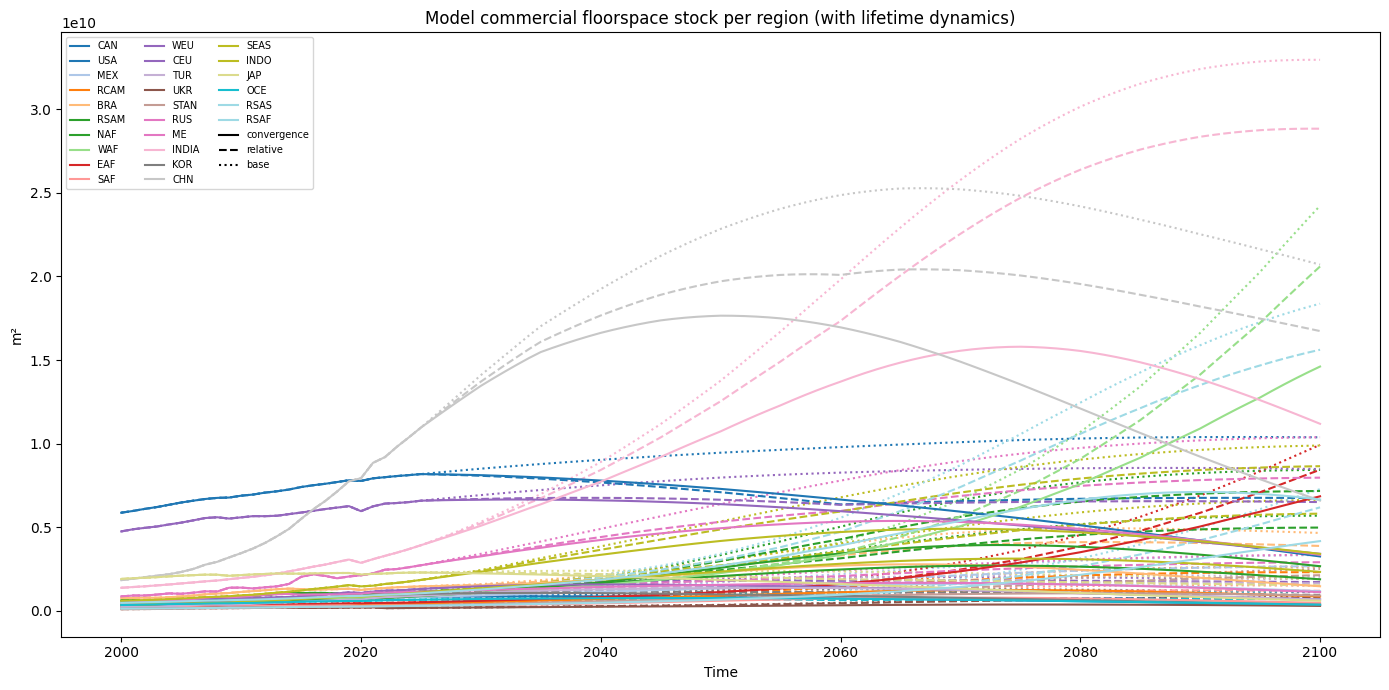

In [8]:

# --- Model stocks per region (with lifetime dynamics), all commercial types summed ---
fig, ax = plt.subplots(figsize=(14, 7))

for scen, label in scen_labels.items():
    ls = scen_styles[scen]
    stock_all = model_results[scen]["stocks"].sel(Type=comm_types_plot).sum("Type")
    for reg in all_regions:
        series = stock_all.sel(Region=reg).loc[2000:]
        if prism.U_(series) is not None:
            series = series.pint.to("m**2")
        series.plot(ax=ax, linestyle=ls, color=region_colors[reg])

# Legend: one entry per region + one per scenario linestyle
handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="convergence"))
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="relative"))
handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle=":", label="base"))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Model commercial floorspace stock per region (with lifetime dynamics)")
ax.set_ylabel("m²")

plt.tight_layout()
plt.show()


# Exploring commercial floorspace intermediate data (CE = None)

Step through the individual functions behind `get_image_floorspace` to inspect
`service_value_added`, `commercial_m2_cap_sum`, and `commercial_m2_cap`.

In [9]:
from imagematerials.buildings.preprocessing.floorspace import (
    get_gompertz,
    get_service_value_added,
    compute_commercial_floor_m2_cap_sum,
    compute_commercial_floor_m2_cap,
)

image_directory = Path(climate_config["config_file_path"])

# 1. Gompertz parameters
gompertz = get_gompertz(base_dir)
print("Gompertz parameters:")
display(gompertz)

# 2. Service value added (inflation-adjusted)
service_value_added = get_service_value_added(image_directory)
print(f"\nService value added shape: {service_value_added.shape}")
display(service_value_added.head(10))

# 3. Total commercial floorspace per capita (summed across types)
commercial_m2_cap_sum = compute_commercial_floor_m2_cap_sum(gompertz, service_value_added)
print(f"\ncommercial_m2_cap_sum shape: {commercial_m2_cap_sum.shape}")
display(commercial_m2_cap_sum.head(10))

# 4. Commercial floorspace per capita by type
commercial_m2_cap, minimum_comm = compute_commercial_floor_m2_cap(
    gompertz, commercial_m2_cap_sum, service_value_added
)
print(f"\ncommercial_m2_cap shape: {commercial_m2_cap.shape}")
display(commercial_m2_cap.head(10))
print(f"\nMinimum commercial values:\n{minimum_comm}")

Gompertz parameters:


,All,Office,Retail+,Govt+,Hotels+
a,25.600531,4.2530,8.0100,9.9800,3.0830
b,3.289102,5.5400,6.5240,2.6520,4.5270
c,0.072218,0.0695,0.0633,0.0517,0.0479



Service value added shape: (131, 28)


,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
time,,,,,,,,,,,,,,,,,,,,,
1970,13989.652107,17894.747619,6466.942968,3525.429997,4119.081687,4687.869984,2555.515453,1355.897154,670.844982,7074.697247,...,1030.778051,168.839378,1075.761237,703.897491,8670.391844,10789.459976,831.850167,1225.764366,0.0,3512.572192
1971,13989.652107,17894.747619,6466.942968,3525.429997,4119.081687,4687.869984,2555.515453,1355.897154,670.844982,7074.697247,...,1030.778051,168.839378,1075.761237,703.897491,8670.391844,10789.459976,831.850167,1225.764366,0.0,3512.572192
1972,14613.845742,18580.695987,6866.246761,3669.309457,4563.892171,4668.596942,2740.879036,1398.963968,645.279690,6850.674531,...,1076.587864,175.678115,1077.273116,750.503742,9386.643636,10777.089153,737.089511,1223.970857,0.0,3655.527380
1973,14800.923699,19208.827713,7145.700904,3768.200263,4878.494708,4757.005222,2660.368058,1421.055789,626.040190,6770.494004,...,1184.565226,183.835554,1105.142875,781.065813,9867.857237,11108.959660,719.397792,1255.208739,0.0,3758.933948
1974,14851.100196,19133.892177,7145.391571,3743.760496,5094.436263,4713.191785,2324.320939,1442.991080,637.176664,6717.983225,...,1299.358839,184.086747,1080.016860,810.259863,9917.699555,11687.210556,737.979867,1247.297773,0.0,3745.027642
1975,15350.144529,19086.982929,7334.844806,3784.693038,5335.403952,4962.195913,2619.590803,1459.216761,679.200816,6669.067663,...,1352.388899,184.335704,1114.910955,872.527293,10473.899627,11883.529983,718.145306,1211.034415,0.0,3826.706382
1976,16242.202890,19856.115705,7494.630674,3876.639388,5740.983844,4891.776137,2736.179415,1500.305833,708.946944,6706.534189,...,1499.203913,185.655772,1176.128145,908.738847,10820.353493,12132.814870,763.947416,1161.320178,0.0,3972.453018
1977,16598.171532,20508.646203,7374.388457,4062.891216,5871.247695,5122.814122,2933.360998,1586.130129,720.040558,6606.219706,...,1664.699392,209.628559,1245.420658,953.327355,11385.108042,12191.846481,765.748130,1127.002510,0.0,4110.796788
1978,17023.535052,21434.122434,7781.466563,4227.727034,6137.181887,5238.484675,3238.810268,1501.385392,710.076691,6461.324045,...,1813.175361,231.093888,1335.435231,1011.683279,11906.425572,12291.593233,811.498933,1085.971328,0.0,4250.907109


C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:263: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
C:\Users\5982758\repos\imag

...

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
1970,7.729349,10.374181,3.256984,1.999331,2.225137,2.455002,1.661644,1.297338,1.115229,3.5585,...,4.212056,1.074496,1.2086,0.993394,1.220628,1.123592,4.41109,5.661292,1.156368,1.261315
1971,7.729349,10.374181,3.256984,1.999331,2.225137,2.455002,1.661644,1.297338,1.115229,3.5585,...,4.212056,1.074496,1.2086,0.993394,1.220628,1.123592,4.41109,5.661292,1.156368,1.261315
1972,8.148313,10.837117,3.453572,2.052728,2.403779,2.446998,1.723183,1.309408,1.10879,3.445796,...,4.829289,1.070727,1.22085,0.994989,1.221034,1.135457,4.819979,5.653661,1.132033,1.260823
1973,8.27446,11.258247,3.594596,2.089923,2.53497,2.483836,1.69628,1.315629,1.103961,3.405898,...,4.627158,1.063969,1.250051,0.996894,1.228527,1.143283,5.102873,5.859537,1.127529,1.269406
1974,8.308332,11.208171,3.594438,2.080693,2.62732,2.46554,1.586869,1.321825,1.106754,3.379896,...,3.701235,1.066876,1.281604,0.996953,1.22177,1.150793,5.132529,6.223794,1.13226,1.267229
1975,8.64598,11.1768,3.691621,2.096165,2.732563,2.570544,1.682757,1.326421,1.11734,3.355764,...,4.36227,1.082562,1.296358,0.997011,1.231161,1.166922,5.467762,6.348947,1.12721,1.25728
1976,9.251831,11.688664,3.77456,2.131171,2.914863,2.540596,1.721605,1.338106,1.124874,3.37424,...,4.901143,1.084638,1.337791,0.99732,1.247753,1.176372,5.680362,6.508872,1.138895,1.243726
1977,9.493931,12.118191,3.712064,2.203144,2.974771,2.639594,1.788583,1.362731,1.127692,3.324888,...,5.466233,1.086433,1.385535,1.002934,1.266713,1.188079,6.032648,6.546902,1.139356,1.234426
1978,9.783149,12.718542,3.925645,2.268026,3.099098,2.689957,1.895503,1.338413,1.12516,3.25426,...,5.609338,1.093292,1.429311,1.00798,1.291629,1.203519,6.363589,6.611294,1.151112,1.223369
1979,9.836073,12.996886,4.148444,2.263253,3.21597,2.736725,1.866544,1.312192,1.122963,3.141226,...,5.039972,1.086037,1.469495,1.007866,1.299515,1.207203,6.790167,6.656462,1.15903,1.216936


C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:302: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)
C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:321: PerformanceWarning: indexing past lexsort depth may impact performance.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
C:\Users\5982758\repos\image-materials\imagematerials\buildings\preprocessing\floorspace.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9799928090094342' has dtype incompatible with int64, please explicitly cast to a compat


commercial_m2_cap shape: (3406, 4)


Type            Govt+   Hotels+    Office   Retail+
Region Time                                        
1      1970  0.000000  0.000000  0.000000  0.000000
       1971  5.162520  0.569578  0.979993  1.017259
       1972  5.351873  0.606854  1.065995  1.123591
       1973  5.407651  0.618143  1.092210  1.156455
       1974  5.422534  0.621179  1.099273  1.165346
       1975  5.568724  0.651566  1.170212  1.255478
       1976  5.821571  0.706628  1.299699  1.423933
       1977  5.919362  0.728826  1.352142  1.493601
       1978  6.033860  0.755490  1.415255  1.578544
       1979  6.054544  0.760386  1.426855  1.594288


Minimum commercial values:
<xarray.DataArray (Type: 4)> Size: 32B
array([0.01781442, 0.0126013 , 0.03457471, 0.72009772])
Coordinates:
  * Type     (Type) <U7 112B 'Office' 'Retail+' 'Hotels+' 'Govt+'


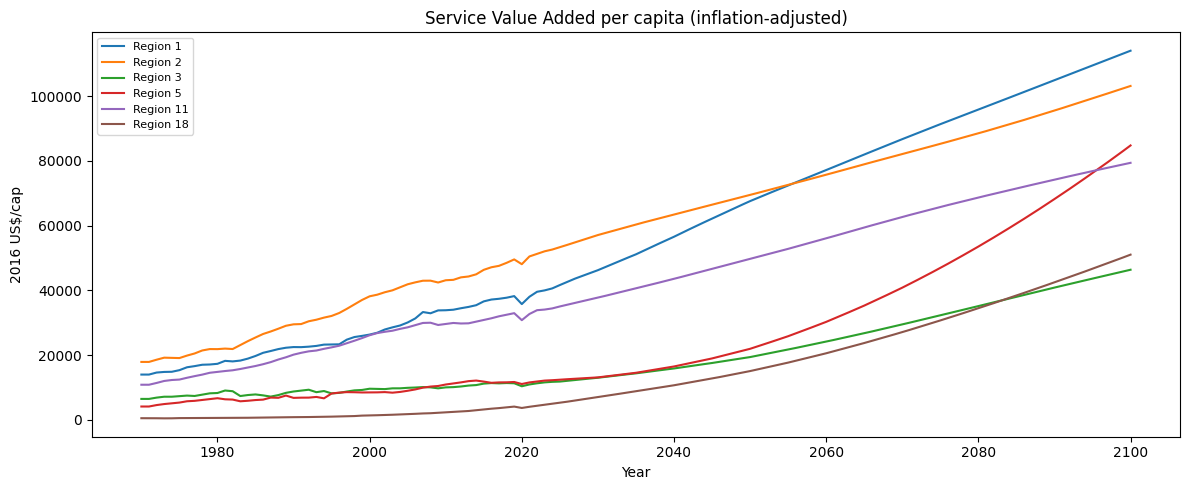

In [10]:
# --- Plot service_value_added for a selection of regions ---
fig, ax = plt.subplots(figsize=(12, 5))
sample_regions = [1, 2, 3, 5, 11, 18]  # a handful of IMAGE regions
for reg in sample_regions:
    if reg in service_value_added.columns:
        service_value_added[reg].plot(ax=ax, label=f"Region {reg}")
ax.set_title("Service Value Added per capita (inflation-adjusted)")
ax.set_ylabel("2016 US$/cap")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

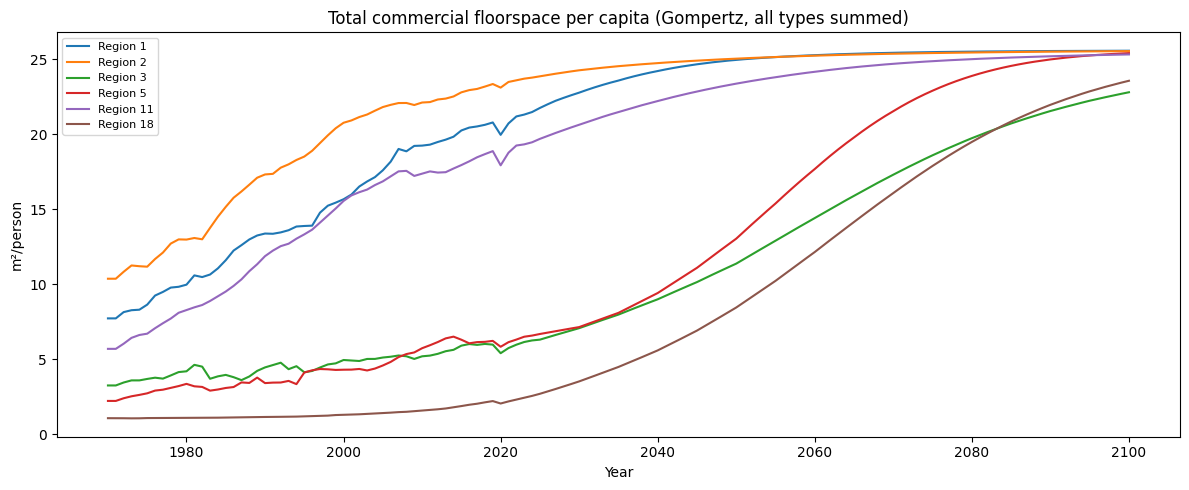

In [11]:
# --- Plot commercial_m2_cap_sum (total commercial m²/cap) for selected regions ---
fig, ax = plt.subplots(figsize=(12, 5))
for reg in sample_regions:
    if reg in commercial_m2_cap_sum.columns:
        commercial_m2_cap_sum[reg].astype(float).plot(ax=ax, label=f"Region {reg}")
ax.set_title("Total commercial floorspace per capita (Gompertz, all types summed)")
ax.set_ylabel("m²/person")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()